# Early Sepsis Alert System — Model Evaluation

This notebook evaluates the performance of the trained early sepsis
prediction system using saved model predictions.

Evaluation includes:

• Model-level metrics (ROC-AUC, PR-AUC)  
• Alert system behaviour  
• Patient-level detection performance  
• Early warning analysis  
• Alert fatigue analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

In [2]:
df = pd.read_csv(
    "/content/drive/MyDrive/physionet/model_predictions.csv"
)

print("Dataset shape:", df.shape)
print("Patients:", df["PatientID"].nunique())

df.head()

Dataset shape: (159102, 59)
Patients: 4068


,HR,O2Sat,SBP,MAP,Resp,Temp,Lactate,WBC,Creatinine,Platelets,...,tachycardia,hypotension,tachypnea,prob,uncertain,prob_filtered,high_risk,high_risk_prev,alert_raw,alert
0,84.0,98.0,118.0,77.00,18.0,36.94,NaN,NaN,NaN,NaN,...,0,0,0,0.009186,False,0.009186,0,0.0,0,0
1,97.0,95.0,98.0,75.33,19.0,36.94,NaN,NaN,NaN,NaN,...,0,0,0,0.008769,False,0.008769,0,0.0,0,0
2,89.0,99.0,122.0,86.00,22.0,36.94,NaN,NaN,NaN,NaN,...,0,0,0,0.003588,False,0.003588,0,0.0,0,0
3,90.0,95.0,122.0,86.00,30.0,36.94,NaN,NaN,NaN,NaN,...,0,0,1,0.007475,False,0.007475,0,0.0,0,0
4,103.0,88.5,122.0,91.33,24.5,36.94,NaN,NaN,NaN,NaN,...,1,0,1,0.009939,False,0.009939,0,0.0,0,0


Overview Dataset

In [3]:
print("Total rows:", len(df))

print("Total patients:",
      df["PatientID"].nunique())

print("Sepsis positives:",
      df["FutureSepsis"].sum())

print("Sepsis rate:",
      df["FutureSepsis"].mean())

Total rows: 159102
Total patients: 4068
Sepsis positives: 1747
Sepsis rate: 0.010980377367977774


### Model Level Matrix

In [4]:
roc = roc_auc_score(df["FutureSepsis"], df["prob"])

pr = average_precision_score(
    df["FutureSepsis"],
    df["prob"]
)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.756004458507216
PR-AUC: 0.0399172981371418


### ROC Curve

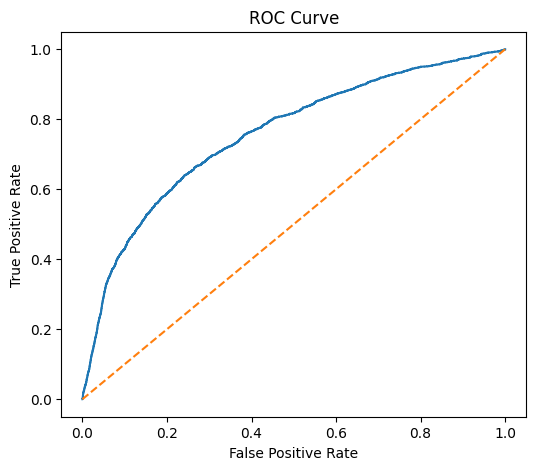

In [5]:
fpr, tpr, thresholds = roc_curve(
    df["FutureSepsis"],
    df["prob"]
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

### Precision Recall Curve

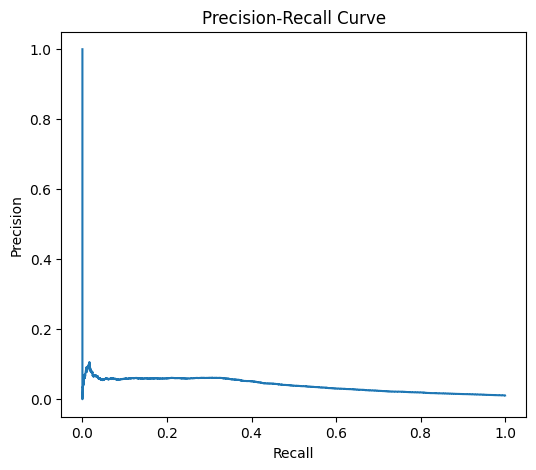

In [6]:
precision, recall, thresholds = precision_recall_curve(
    df["FutureSepsis"],
    df["prob"]
)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

### Alert Statistics

In [7]:
total_alerts = df["alert"].sum()

patients = df["PatientID"].nunique()

alerts_per_patient = df.groupby("PatientID")["alert"].sum()

print("Total alerts:", total_alerts)

print("Average alerts per patient:",
      alerts_per_patient.mean())

print("Max alerts for one patient:",
      alerts_per_patient.max())

Total alerts: 2230
Average alerts per patient: 0.548180924287119
Max alerts for one patient: 76


### Patient Level evaluation

In [16]:
patient_alerts = df.groupby("PatientID").agg({
    "alert":"max",
    "FutureSepsis":"max"
}).reset_index()

patient_alerts.head()

,PatientID,alert,FutureSepsis
0,p000001,0,0
1,p000004,0,0
2,p000007,0,0
3,p000018,1,1
4,p000020,0,0


### Patient Confusion Matrix

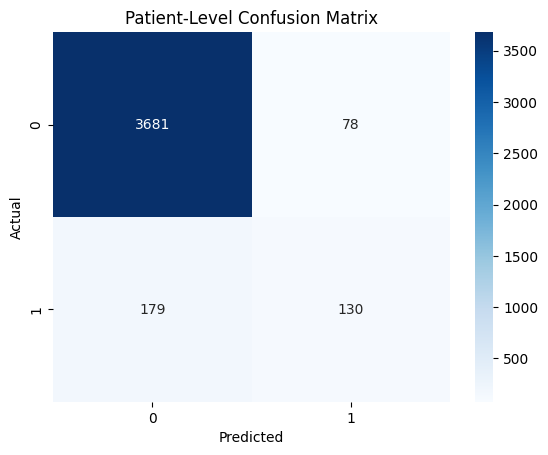

In [9]:
cm = confusion_matrix(
    patient_alerts["FutureSepsis"],
    patient_alerts["alert"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Patient-Level Confusion Matrix")

plt.show()

### Patient Level Matrix

In [10]:
precision = precision_score(
    patient_alerts["FutureSepsis"],
    patient_alerts["alert"]
)

recall = recall_score(
    patient_alerts["FutureSepsis"],
    patient_alerts["alert"]
)

f1 = f1_score(
    patient_alerts["FutureSepsis"],
    patient_alerts["alert"]
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.625
Recall: 0.42071197411003236
F1 Score: 0.5029013539651838


### Early Warning Analysis

In [11]:
alerts = df[df["alert"] == 1]

first_alert = alerts.groupby("PatientID")["ICULOS"].min()

sepsis_rows = df[df["FutureSepsis"] == 1]

sepsis_onset = sepsis_rows.groupby("PatientID")["ICULOS"].min()

warning_df = (
    first_alert.to_frame("alert_time")
    .merge(
        sepsis_onset.to_frame("sepsis_time"),
        left_index=True,
        right_index=True,
        how="inner"
    )
)

warning_df["hours_early"] = (
    warning_df["sepsis_time"] -
    warning_df["alert_time"]
)

warning_df = warning_df[
    warning_df["hours_early"] > 0
]

### Early Warning Distribution

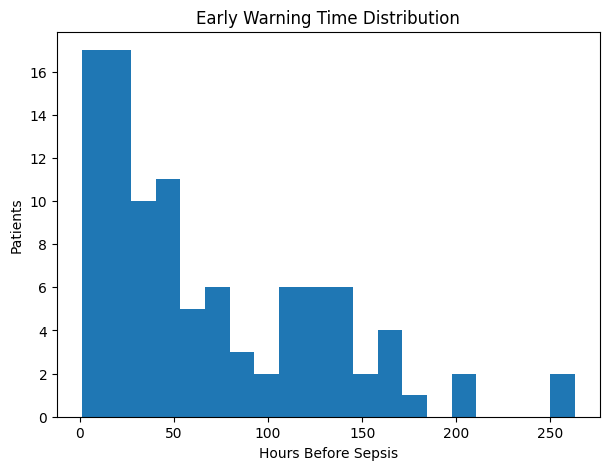

Average early warning: 68.61
Median early warning: 47.0


In [12]:
plt.figure(figsize=(7,5))

plt.hist(
    warning_df["hours_early"],
    bins=20
)

plt.xlabel("Hours Before Sepsis")
plt.ylabel("Patients")

plt.title("Early Warning Time Distribution")

plt.show()

print("Average early warning:",
      warning_df["hours_early"].mean())

print("Median early warning:",
      warning_df["hours_early"].median())

### Clinical Window (0–24h)

In [13]:
clinical_window = warning_df[
    (warning_df["hours_early"] > 0) &
    (warning_df["hours_early"] <= 24)
]

print("Patients warned within 24h:",
      clinical_window.shape[0])

print("Average warning time:",
      clinical_window["hours_early"].mean())

Patients warned within 24h: 32
Average warning time: 13.59375


### Clinical Early Warning Check (0–24h Window)

In [17]:
# find sepsis onset time
sepsis_onset = df[df["FutureSepsis"] == 1] \
    .groupby("PatientID")["ICULOS"].min()

# all alerts
alerts = df[df["alert"] == 1][["PatientID","ICULOS"]]

# merge alerts with sepsis time
alerts = alerts.merge(
    sepsis_onset.rename("sepsis_time"),
    on="PatientID",
    how="inner"
)

# compute early warning time
alerts["hours_early"] = alerts["sepsis_time"] - alerts["ICULOS"]

# alerts inside clinical window
alerts_24h = alerts[
    (alerts["hours_early"] > 0) &
    (alerts["hours_early"] <= 24)
]

clinical_patients = alerts_24h["PatientID"].nunique()

print("Septic patients warned within 24h:", clinical_patients)

Septic patients warned within 24h: 96


### Clinical Detection Rate

In [18]:
# total septic patients in test set
total_septic = df.groupby("PatientID")["FutureSepsis"].max().sum()

print("Total septic patients:", int(total_septic))

print("Clinical detection rate:",
      clinical_patients / total_septic)

Total septic patients: 309
Clinical detection rate: 0.3106796116504854


### Risk Trajectory Visualization

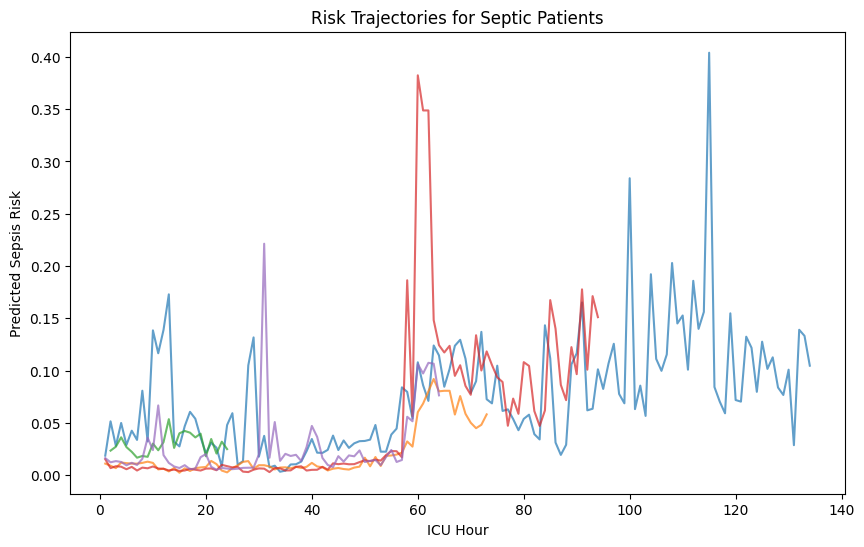

In [14]:
septic_patients = df.groupby("PatientID")["FutureSepsis"].max()

septic_patients = septic_patients[
    septic_patients == 1
].index[:5]

plt.figure(figsize=(10,6))

for pid in septic_patients:

    p = df[df["PatientID"] == pid]

    p = p.sort_values("ICULOS")

    plt.plot(
        p["ICULOS"],
        p["prob"],
        alpha=0.7
    )

plt.xlabel("ICU Hour")
plt.ylabel("Predicted Sepsis Risk")

plt.title("Risk Trajectories for Septic Patients")

plt.show()

### Clinical Detection Rate

In [15]:
total_septic = df.groupby(
    "PatientID"
)["FutureSepsis"].max().sum()

clinical_detected = clinical_window.shape[0]

print("Total septic patients:",
      int(total_septic))

print("Clinically useful warnings:",
      clinical_detected)

print("Clinical detection rate:",
      clinical_detected / total_septic)

Total septic patients: 309
Clinically useful warnings: 32
Clinical detection rate: 0.10355987055016182
